In [54]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision.transforms import  ToTensor


In [55]:
# We will be using FashionMNIST Dataset.

# root path
root="../../datasets"

# this is our training dataset
train_dataset = datasets.FashionMNIST(
    root=root,
    train=True,
    download=True,
    transform=ToTensor()
)

# this is our test dataset
test_dataset = datasets.FashionMNIST(
    root=root,
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataset, test_dataset

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: ../../datasets
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: ../../datasets
     Split: Test
     StandardTransform
 Transform: ToTensor())

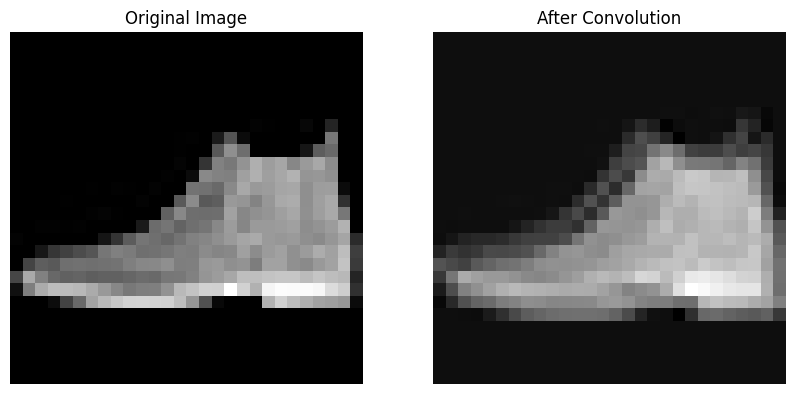

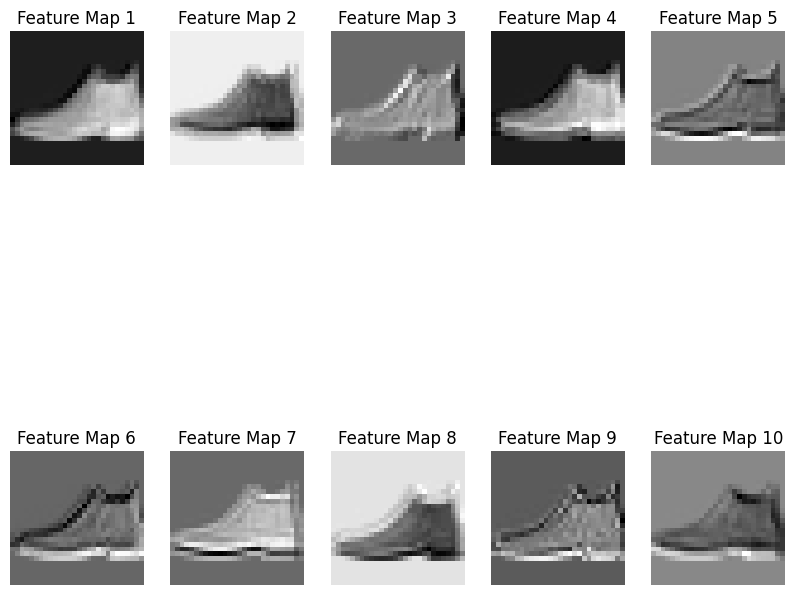

In [56]:
torch.manual_seed(42)

# lets view image after one convolution layer
conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    stride=1,
    padding=1
)

conv_parsed_img = conv(test_dataset[0][0])
plt.figure(figsize=(10,10))

plt.subplot(1, 2, 1)
plt.imshow(test_dataset[0][0].squeeze().detach().numpy(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2) # (row, coloumn, position)
plt.imshow(conv_parsed_img.squeeze().detach().numpy(), cmap="gray")
plt.title("After Convolution")
plt.axis("off")

plt.show()

conv_parsed_img

# this is for mutliple filters and outchannels will product 10 feature maps that would be 10 different image representation of same image
conv2 = nn.Conv2d(
    in_channels=1,
    out_channels=10,
    kernel_size=3,
    stride=1,
    padding=1
)

conv_parsed_img_2 = conv2(test_dataset[0][0])
plt.figure(figsize=(10,10))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(conv_parsed_img_2[i].detach().numpy(), cmap="gray")
    plt.title(f"Feature Map {i+1}")
    plt.axis("off")

plt.show()

# now lets apply non linearity on this so that it can learn complex pattern

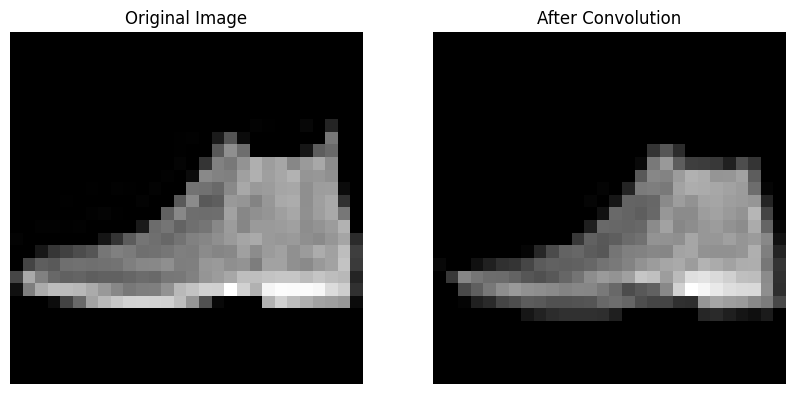

In [57]:
# here we are working with model one with single out_channels (single feature map against each image)

conv_parsed_img = torch.relu(conv_parsed_img)
plt.figure(figsize=(10,10))

plt.subplot(1, 2, 1)
plt.imshow(test_dataset[0][0].squeeze().detach().numpy(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2) # (row, coloumn, position)
plt.imshow(conv_parsed_img.squeeze().detach().numpy(), cmap="gray")
plt.title("After Convolution")
plt.axis("off")

plt.show()


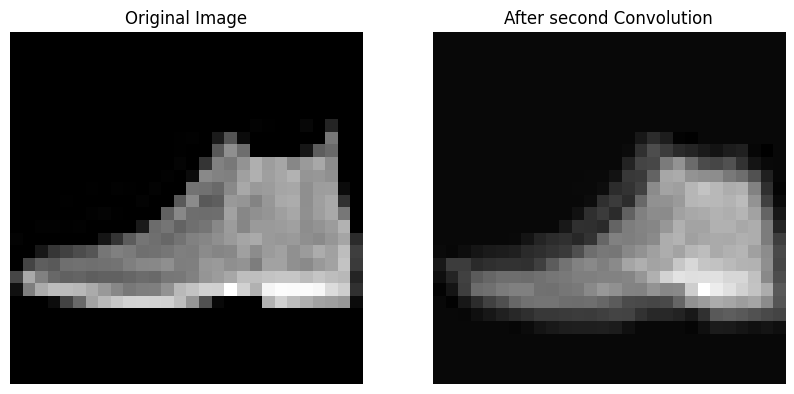

In [58]:
# here we are working with model one with single out_channels (single feature map against each image)

conv_parsed_img = conv(conv_parsed_img)
plt.figure(figsize=(10,10))

plt.subplot(1, 2, 1)
plt.imshow(test_dataset[0][0].squeeze().detach().numpy(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2) # (row, coloumn, position)
plt.imshow(conv_parsed_img.squeeze().detach().numpy(), cmap="gray")
plt.title("After second Convolution")
plt.axis("off")

plt.show()


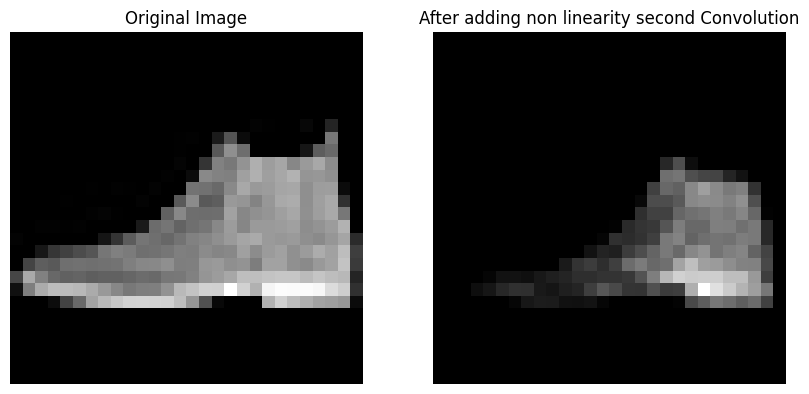

In [59]:
# here we are working with model one with single out_channels (single feature map against each image)

conv_parsed_img = torch.relu(conv_parsed_img)
plt.figure(figsize=(10,10))

plt.subplot(1, 2, 1)
plt.imshow(test_dataset[0][0].squeeze().detach().numpy(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2) # (row, coloumn, position)
plt.imshow(conv_parsed_img.squeeze().detach().numpy(), cmap="gray")
plt.title("After adding non linearity second Convolution")
plt.axis("off")

plt.show()


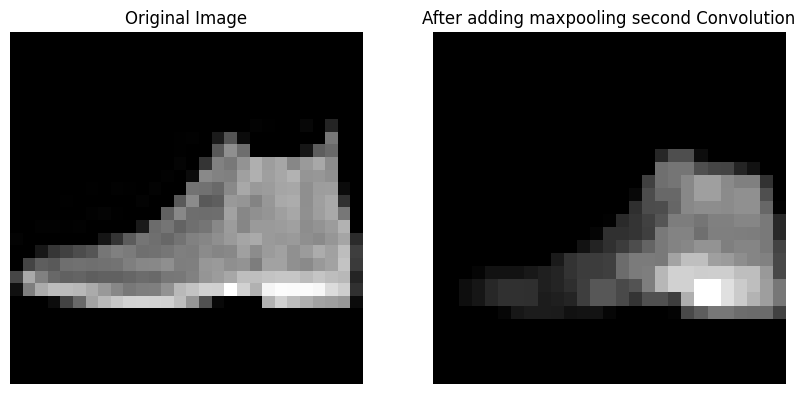

In [ ]:
# here we are working with model one with single out_channels (single feature map against each image)

max_pool = nn.MaxPool2d(
    kernel_size=2,
    stride=1
)

conv_parsed_img = max_pool(conv_parsed_img)

plt.figure(figsize=(10,10))

plt.subplot(1, 2, 1)
plt.imshow(test_dataset[0][0].squeeze().detach().numpy(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2) # (row, coloumn, position)
plt.imshow(conv_parsed_img.squeeze().detach().numpy(), cmap="gray")
plt.title("After adding maxpooling second Convolution")
plt.axis("off")

plt.show()
